# Lighthouse EDA (Postgres Source of Truth)

This notebook pulls data directly from PostgreSQL and performs a first-pass exploratory data analysis (EDA).

- Source of truth: PostgreSQL (`lighthouse` schema)
- CSV files are intentionally not used in this notebook
- Focus: shape/quality checks + key relationships across residents, donations, incidents, and safehouse metrics

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# Optional helper functions (as requested)
helper_path = Path('/Users/nathanblatter/Desktop/IS455')
if helper_path.exists() and str(helper_path) not in sys.path:
    sys.path.append(str(helper_path))

try:
    from library import univariate, basicWrangling, missing_data
    HAS_HELPERS = True
except Exception as exc:
    HAS_HELPERS = False
    print(f"Helper import unavailable: {exc}")

In [2]:
# Load .env values without requiring external packages
# (Robust to running the notebook from repo root *or* from inside ./is455)


def load_env_file(path: Path) -> bool:
    if not path.exists():
        return False
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        os.environ[key.strip()] = value.strip().strip('"').strip("'")
    return True


def find_env_file() -> Path | None:
    # Try common locations first
    candidates = [
        Path('is455/.env'),
        Path('.env'),
    ]

    # Walk upward a few levels (handles odd Jupyter working dirs)
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents][:6]:
        candidates.extend([
            p / 'is455' / '.env',
            p / '.env',
        ])

    for c in candidates:
        if c.exists():
            return c
    return None


env_path = find_env_file()
if env_path is None:
    raise FileNotFoundError(
        "Could not find a .env file. Expected at 'is455/.env' (recommended) or '.env'."
    )

loaded = load_env_file(env_path)
print(f"Loaded env file: {env_path} (loaded={loaded})")

required = ['PGHOST', 'PGPORT', 'PGDATABASE', 'PGUSER', 'PGPASSWORD']
missing = [k for k in required if not os.getenv(k)]
if missing:
    raise ValueError(f"Missing required env vars: {missing}. Check {env_path}.")

sslmode = os.getenv('PGSSLMODE', 'disable')

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
    f"?sslmode={sslmode}"
)

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    schema_check = pd.read_sql(
        text("select schema_name from information_schema.schemata where schema_name='lighthouse';"),
        conn,
    )

print('Connected to Postgres')
print('lighthouse schema found:', not schema_check.empty)

Loaded env file: .env (loaded=True)
Connected to Postgres
lighthouse schema found: True


In [3]:
# Load all tables from the authoritative lighthouse schema

def get_lighthouse_tables(conn):
    q = text("""
        select table_name
        from information_schema.tables
        where table_schema = 'lighthouse'
          and table_type = 'BASE TABLE'
        order by table_name;
    """)
    return pd.read_sql(q, conn)['table_name'].tolist()

with engine.connect() as conn:
    table_names = get_lighthouse_tables(conn)

table_names

['donation_allocations',
 'donations',
 'education_records',
 'health_wellbeing_records',
 'home_visitations',
 'in_kind_donation_items',
 'incident_reports',
 'intervention_plans',
 'partner_assignments',
 'partners',
 'process_recordings',
 'public_impact_snapshots',
 'residents',
 'safehouse_monthly_metrics',
 'safehouses',
 'social_media_posts',
 'supporters']

In [4]:
dfs = {}
with engine.connect() as conn:
    for t in table_names:
        dfs[t] = pd.read_sql(text(f'SELECT * FROM lighthouse."{t}";'), conn)

shape_summary = (
    pd.DataFrame({
        'table': list(dfs.keys()),
        'rows': [df.shape[0] for df in dfs.values()],
        'cols': [df.shape[1] for df in dfs.values()]
    })
    .sort_values('rows', ascending=False)
    .reset_index(drop=True)
)

shape_summary

,table,rows,cols
0,process_recordings,2819,15
1,home_visitations,1337,14
2,social_media_posts,812,39
3,education_records,534,10
4,health_wellbeing_records,534,14
5,donation_allocations,521,7
6,safehouse_monthly_metrics,450,11
7,donations,420,13
8,intervention_plans,180,11
9,in_kind_donation_items,129,9


In [5]:
# Quick data quality scan: missingness by table/column

missing_report_frames = []
for t, df in dfs.items():
    if df.empty:
        continue
    miss = df.isna().mean().rename('missing_pct').reset_index()
    miss.columns = ['column', 'missing_pct']
    miss['table'] = t
    missing_report_frames.append(miss)

missing_report = pd.concat(missing_report_frames, ignore_index=True)
missing_report = missing_report[missing_report['missing_pct'] > 0].sort_values('missing_pct', ascending=False)

missing_report.head(30)

,column,missing_pct,table
6,allocation_notes,1.000000,donation_allocations
192,notes,1.000000,safehouse_monthly_metrics
205,notes,1.000000,safehouses
181,notes_restricted,1.000000,residents
125,notes_restricted,1.000000,process_recordings
155,pwd_type,0.950000,residents
248,organization_name,0.933333,supporters
243,subscriber_count_at_post,0.912562,social_media_posts
242,avg_view_duration_seconds,0.912562,social_media_posts
241,watch_time_seconds,0.912562,social_media_posts


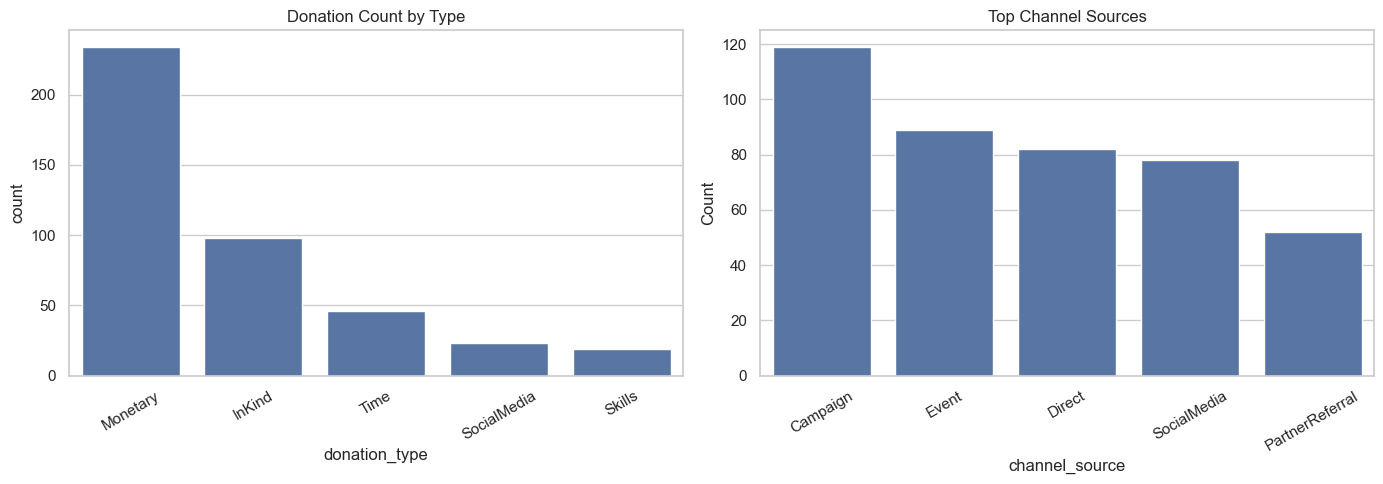

In [6]:
# Relationship 1: donation behavior by type and channel

donations = dfs.get('donations', pd.DataFrame()).copy()
if not donations.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(data=donations, x='donation_type', order=donations['donation_type'].value_counts().index, ax=axes[0])
    axes[0].set_title('Donation Count by Type')
    axes[0].tick_params(axis='x', rotation=30)

    channel_counts = donations['channel_source'].value_counts().head(10)
    sns.barplot(x=channel_counts.index, y=channel_counts.values, ax=axes[1])
    axes[1].set_title('Top Channel Sources')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

    donations[['amount', 'estimated_value']].describe().T
else:
    print('donations table is empty or missing')

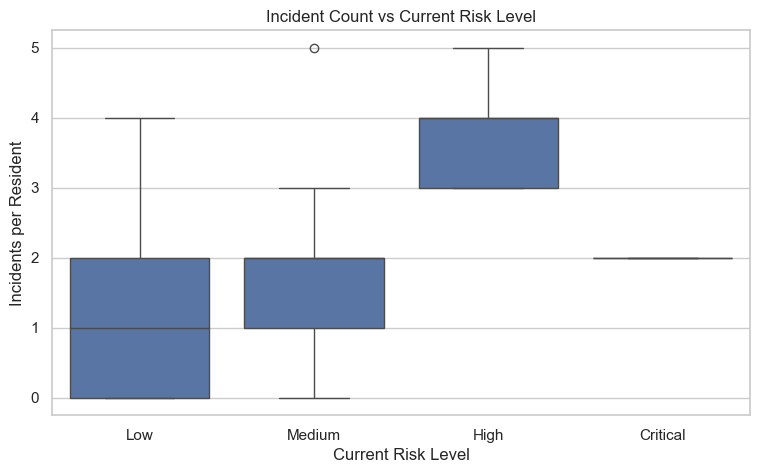

In [7]:
# Relationship 2: incident burden by resident risk level

residents = dfs.get('residents', pd.DataFrame()).copy()
incidents = dfs.get('incident_reports', pd.DataFrame()).copy()

if not residents.empty and not incidents.empty:
    incident_counts = incidents.groupby('resident_id', as_index=False).size().rename(columns={'size': 'incident_count'})
    risk_df = residents[['resident_id', 'current_risk_level', 'initial_risk_level', 'case_status']].merge(
        incident_counts, on='resident_id', how='left'
    )
    risk_df['incident_count'] = risk_df['incident_count'].fillna(0)

    plt.figure(figsize=(9, 5))
    risk_order = ['Low', 'Medium', 'High', 'Critical']
    sns.boxplot(data=risk_df, x='current_risk_level', y='incident_count', order=risk_order)
    plt.title('Incident Count vs Current Risk Level')
    plt.xlabel('Current Risk Level')
    plt.ylabel('Incidents per Resident')
    plt.show()

    risk_df.groupby('current_risk_level', dropna=False)['incident_count'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
else:
    print('residents or incident_reports table is empty/missing')

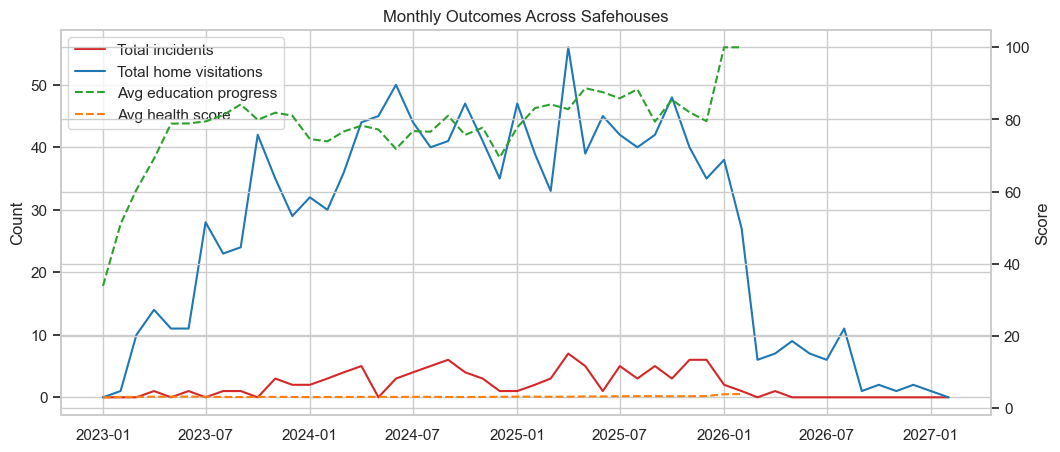

In [8]:
# Relationship 3: safehouse-level monthly trends

metrics = dfs.get('safehouse_monthly_metrics', pd.DataFrame()).copy()
if not metrics.empty:
    metrics['month_start'] = pd.to_datetime(metrics['month_start'])

    monthly = (
        metrics.groupby('month_start', as_index=False)
        .agg(
            avg_education_progress=('avg_education_progress', 'mean'),
            avg_health_score=('avg_health_score', 'mean'),
            incident_count=('incident_count', 'sum'),
            home_visitation_count=('home_visitation_count', 'sum')
        )
        .sort_values('month_start')
    )

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(monthly['month_start'], monthly['incident_count'], label='Total incidents', color='tab:red')
    ax1.plot(monthly['month_start'], monthly['home_visitation_count'], label='Total home visitations', color='tab:blue')
    ax1.set_ylabel('Count')

    ax2 = ax1.twinx()
    ax2.plot(monthly['month_start'], monthly['avg_education_progress'], label='Avg education progress', color='tab:green', linestyle='--')
    ax2.plot(monthly['month_start'], monthly['avg_health_score'], label='Avg health score', color='tab:orange', linestyle='--')
    ax2.set_ylabel('Score')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title('Monthly Outcomes Across Safehouses')
    plt.show()

    monthly.tail(12)
else:
    print('safehouse_monthly_metrics table is empty or missing')

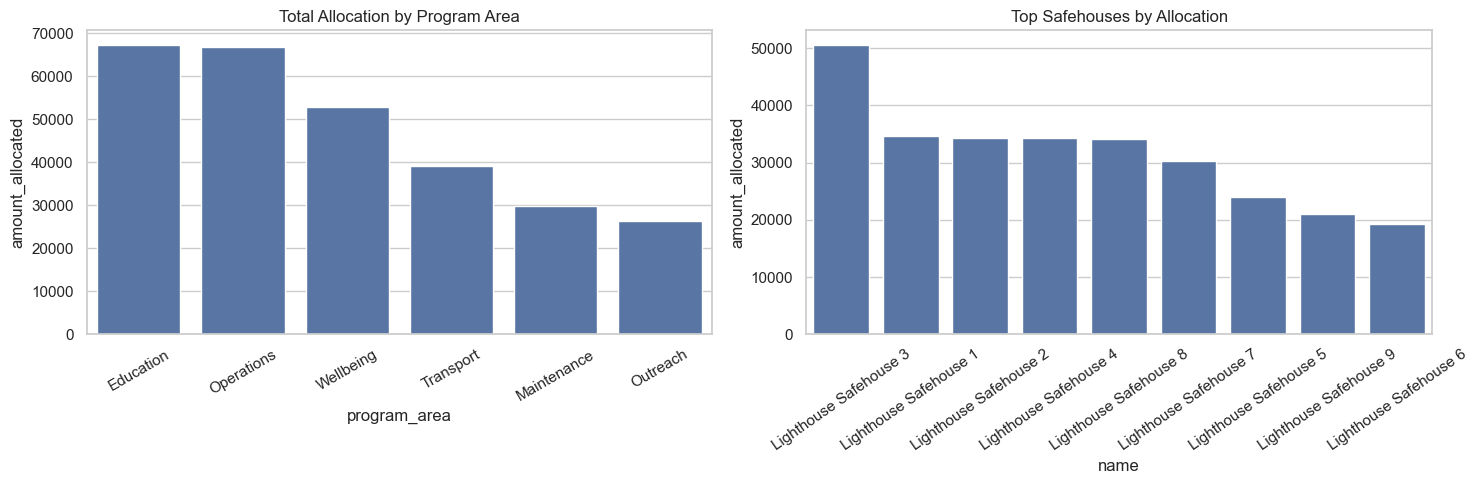

In [9]:
# Relationship 4: where allocated funds are going

alloc = dfs.get('donation_allocations', pd.DataFrame()).copy()
safehouses = dfs.get('safehouses', pd.DataFrame()).copy()

if not alloc.empty:
    alloc_enriched = alloc.merge(
        safehouses[['safehouse_id', 'name']],
        on='safehouse_id',
        how='left'
    )

    area_totals = alloc_enriched.groupby('program_area', as_index=False)['amount_allocated'].sum().sort_values('amount_allocated', ascending=False)
    house_totals = alloc_enriched.groupby('name', dropna=False, as_index=False)['amount_allocated'].sum().sort_values('amount_allocated', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(data=area_totals, x='program_area', y='amount_allocated', ax=axes[0])
    axes[0].set_title('Total Allocation by Program Area')
    axes[0].tick_params(axis='x', rotation=30)

    sns.barplot(data=house_totals.head(10), x='name', y='amount_allocated', ax=axes[1])
    axes[1].set_title('Top Safehouses by Allocation')
    axes[1].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()

    area_totals
else:
    print('donation_allocations table is empty or missing')

/Users/nathanblatter/Desktop/IS455/library.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=plot_data.index, y=plot_data.values, ax=ax, palette='viridis')


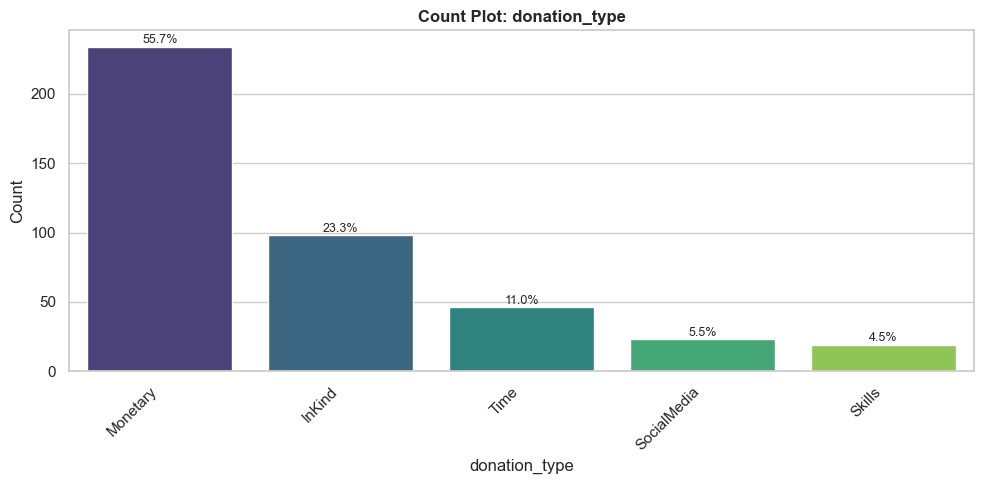

/Users/nathanblatter/Desktop/IS455/library.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=plot_data.index, y=plot_data.values, ax=ax, palette='viridis')


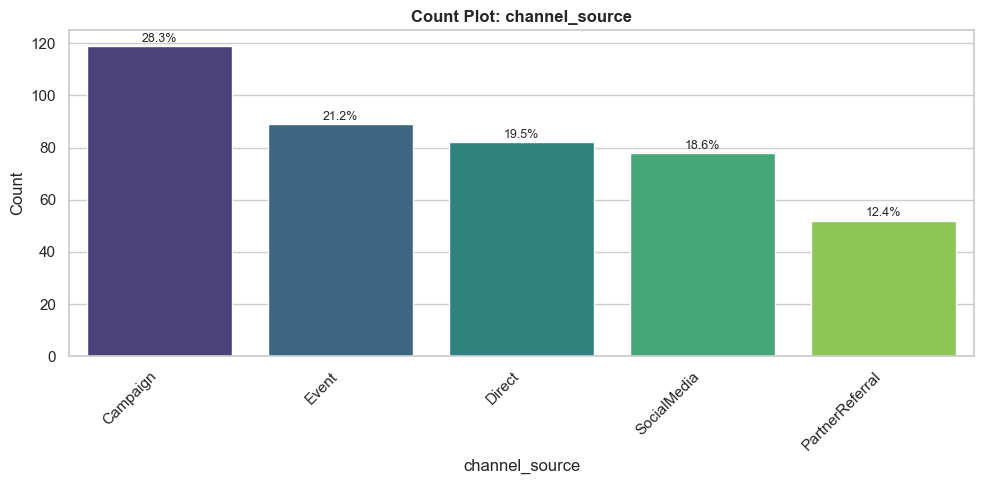

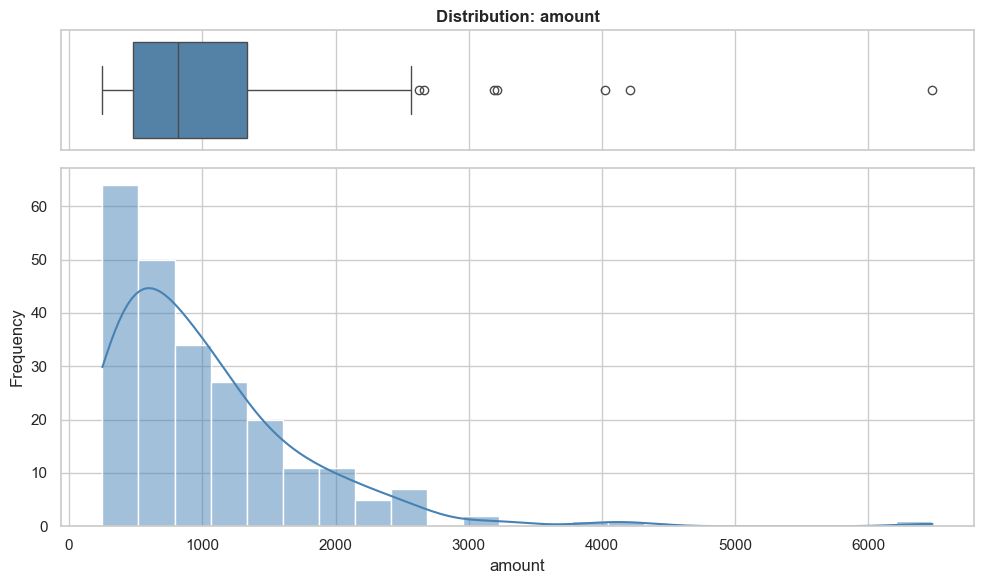

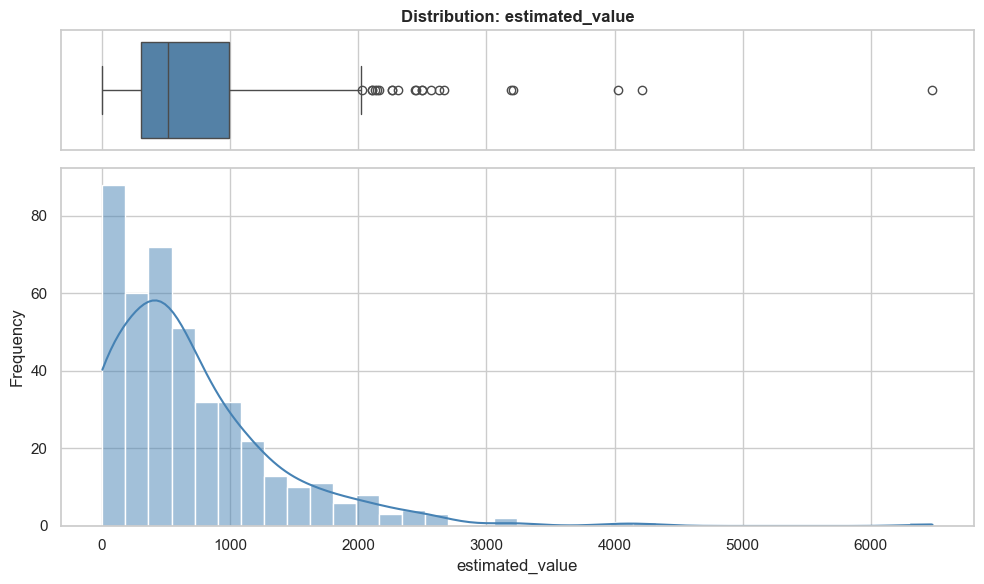

,Data Type,Count,Unique,Missing %,Mode,Min,Q1,Median,Q3,IQR,Max,Mean,Std,Skewness,Kurtosis
donation_type,object,420,5,0.000000,Monetary,,,,,,,,,,
channel_source,object,420,5,0.000000,Campaign,,,,,,,,,,
amount,float64,234,224,44.285714,250.0,250.0,482.5075,819.63,1333.155,850.6475,6481.54,1028.73735,767.59608,2.573858,12.024167
estimated_value,float64,420,390,0.000000,300.0,2.2,300.0,514.16,989.7225,689.7225,6481.54,699.30431,713.251586,2.538575,12.469335


In [12]:
# Optional: run helper function from ./Desktop/IS455/library.py
# This is a lightweight demo; comment out if you do not want many charts.

if HAS_HELPERS and not donations.empty:
    helper_df = donations[['donation_type', 'channel_source', 'amount', 'estimated_value']].copy()

    # pandas 3.x may use string dtype; the helper treats only 'object' as categorical
    for col in ['donation_type', 'channel_source']:
        helper_df[col] = helper_df[col].astype('object')

    # Ensure numeric columns are numeric (Postgres NUMERIC sometimes loads as object/str)
    for col in ['amount', 'estimated_value']:
        helper_df[col] = pd.to_numeric(helper_df[col], errors='coerce')

    helper_summary = univariate(helper_df)
    display(helper_summary)
else:
    print('Helper functions unavailable or donations data missing')